<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/Video_Adversarial_Attacks_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adversarial Attacks and Adversarial Training on Videos: A Fast Tutorial

We train a video classifier that reads an **echocardiogram-style video** of a beating heart and decides whether the **ejection fraction (EF)** is **normal** or **reduced** (a sign of heart failure). Then we show that tiny, invisible changes to the video can flip the diagnosis, and we train a model that resists them.

**Ejection fraction (EF):** the fraction of blood the left ventricle pumps out with each heartbeat, EF = (EDV − ESV) / EDV. Normal is about 55–70%; 40% or less indicates heart failure. In our synthetic 2D videos, EF = 1 − (smallest cavity area / largest cavity area).

| Section | Content |
|---|---|
| 1 | Synthetic echo videos labeled *normal* or *reduced* EF |
| 2 | A small 3D Vision Transformer (ViT-3D) |
| 3 | Standard training |
| 4 | Attacks on the whole video: FGSM and PGD |
| 5 | A video-specific attack: change only **one frame** |
| 6 | Fast adversarial training (FGSM with random start) |
| 7 | Compare: standard vs. adversarially trained model |

**Runtime.** **Runtime → Change runtime type → T4 GPU**. Total time: about 5–10 minutes.

## 1. Data: synthetic echo videos with a diagnosis label

Each clip is one heartbeat: 16 frames of 32 × 32 pixels, values in [−1, 1]. The label is **1 = reduced EF** (EF between 20% and 40%) or **0 = normal EF** (EF between 50% and 70%). We leave out 40–50% so the two classes are clearly separated. Videos are generated on the GPU; you don't need to read the generator in detail.

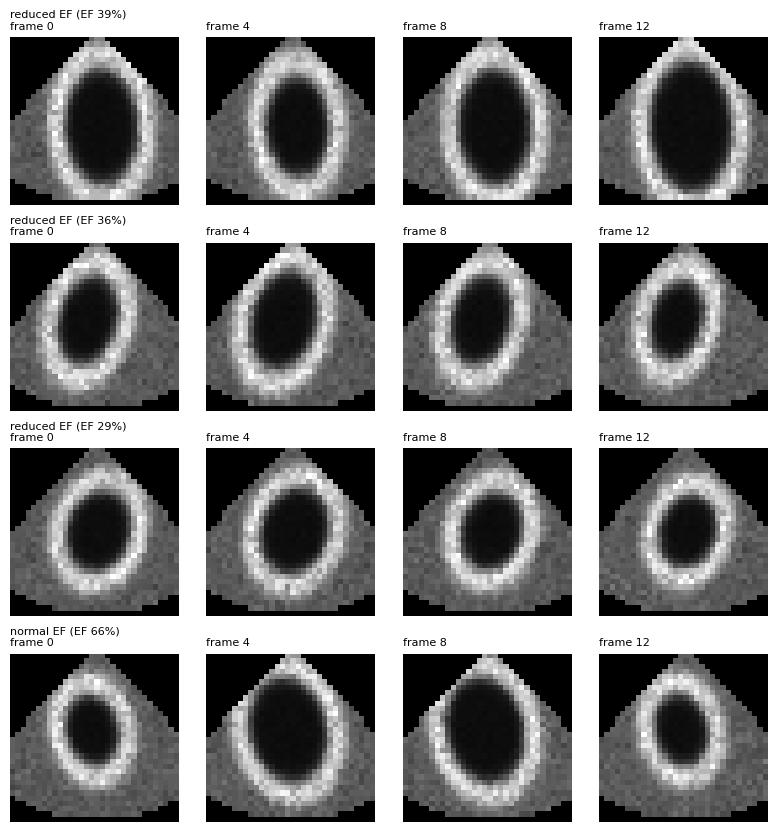

In [1]:
import math, time, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
T, S = 16, 32
CLASSES = ["normal EF", "reduced EF"]

yy, xx = torch.meshgrid(torch.arange(S, device=device).float(), torch.arange(S, device=device).float(), indexing="ij")
fan = ((xx - S / 2).atan2(yy + 2).abs() < 0.75) & ((xx - S / 2) ** 2 + (yy + 2) ** 2 < (S + 1) ** 2)

def make_echo(B):
    """Return B echo clips (B, 1, T, S, S) in [-1, 1], labels (B,), and EF (B,)."""
    r = lambda lo, hi: lo + (hi - lo) * torch.rand(B, 1, 1, 1, device=device)
    y = torch.randint(0, 2, (B,), device=device)                          # 1 = reduced EF
    ef = torch.where(y.view(B, 1, 1, 1) == 1, r(0.2, 0.4), r(0.5, 0.7))
    t = torch.arange(T, device=device).view(1, T, 1, 1) / T
    r_max, aspect, tilt = r(6, 8.5), r(1.3, 1.6), r(-0.35, 0.35)
    cx, cy = r(14, 18), r(14, 18)
    r_min = r_max * (1 - ef).sqrt()
    rad = r_min + (r_max - r_min) * (0.5 + 0.5 * torch.cos(2 * math.pi * (t + r(0, 1))))
    u = (xx - cx) * tilt.cos() + (yy - cy) * tilt.sin()
    v = -(xx - cx) * tilt.sin() + (yy - cy) * tilt.cos()
    dist = ((u / rad) ** 2 + (v / (aspect * rad)) ** 2).sqrt() * rad
    cavity = torch.sigmoid(2 * (rad - dist))
    wall = torch.sigmoid(2 * (rad + 3 - dist)) - cavity
    img = 0.35 * (1 - cavity - wall) + 0.05 * cavity + 0.9 * wall
    img = img * (1 + 0.1 * torch.randn_like(img)).clamp(min=0) * fan
    return (img.clamp(0, 1) * 2 - 1)[:, None], y, ef.view(B)

def show_frames(videos, titles, frames=(0, 4, 8, 12), cmaps=None):
    """One row per video, a few frames each."""
    fig, ax = plt.subplots(len(videos), len(frames), figsize=(2 * len(frames), 2.1 * len(videos)), squeeze=False)
    for r, (v, title) in enumerate(zip(videos, titles)):
        for c, f in enumerate(frames):
            cmap = (cmaps or ["gray"] * len(videos))[r]
            m = v.abs().max().item()
            vmin, vmax = (-1, 1) if cmap == "gray" else (-m, m)          # perturbations: 0 = white
            ax[r, c].imshow(v[0, f].cpu(), cmap=cmap, vmin=vmin, vmax=vmax); ax[r, c].axis("off")
            ax[r, c].set_title(f"{title}\nframe {f}" if c == 0 else f"frame {f}", fontsize=8, loc="left")
    plt.tight_layout(); plt.show()

x_test, y_test, ef_test = make_echo(1000)            # a fixed test set, used for every evaluation
show_frames([x_test[i] for i in range(4)],
            [f"{CLASSES[y_test[i]]} (EF {ef_test[i]:.0%})" for i in range(4)])

## 2. The model: a small 3D Vision Transformer

The same ViT-3D as in the *3D Transformer* tutorial: the video is cut into 2 × 8 × 8 tubelets (8 × 4 × 4 = 128 tokens), 4 Transformer blocks attend across space and time, and a `[CLS]` token is classified into *normal* or *reduced* EF.

In [2]:
class Block(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.norm1, self.attn = nn.LayerNorm(dim), nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(), nn.Linear(4 * dim, dim))
    def forward(self, x):
        h = self.norm1(x)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        return x + self.mlp(self.norm2(x))

class TubeletEmbed(nn.Module):
    """Cut the video into 2 x 8 x 8 tubelets and map each one to a token with a linear layer.
    This equals nn.Conv3d(1, dim, kernel_size=tubelet, stride=tubelet), but its gradient with respect
    to the input video (which every attack needs) is much faster on some GPUs."""
    def __init__(self, dim, tubelet=(2, 8, 8)):
        super().__init__()
        self.t = tubelet
        self.proj = nn.Linear(tubelet[0] * tubelet[1] * tubelet[2], dim)
    def forward(self, x):                                            # (B, 1, T, H, W)
        B, _, Tt, H, W = x.shape
        pt, ph, pw = self.t
        x = x.reshape(B, Tt // pt, pt, H // ph, ph, W // pw, pw)
        x = x.permute(0, 1, 3, 5, 2, 4, 6).reshape(B, -1, pt * ph * pw)   # (B, tokens, voxels per tubelet)
        return self.proj(x)                                          # (B, tokens, dim)

class ViT3D(nn.Module):
    def __init__(self, tubelet=(2, 8, 8), dim=128, depth=4, heads=4, num_classes=2):
        super().__init__()
        self.embed = TubeletEmbed(dim, tubelet)                          # video -> tokens
        n = (T // tubelet[0]) * (S // tubelet[1]) * (S // tubelet[2])
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.randn(1, n + 1, dim) * 0.02)
        self.blocks = nn.Sequential(*[Block(dim, heads) for _ in range(depth)])
        self.norm, self.head = nn.LayerNorm(dim), nn.Linear(dim, num_classes)
    def forward(self, x):
        x = self.embed(x)
        x = torch.cat([self.cls.expand(len(x), -1, -1), x], 1) + self.pos
        return self.head(self.norm(self.blocks(x))[:, 0])

print(f"Parameters: {sum(p.numel() for p in ViT3D().parameters()) / 1e6:.2f} M")

Parameters: 0.83 M


## 3. Standard training

Fresh videos every step, AdamW with a one-cycle learning rate, and mixed precision on the GPU.

The `train` function has one switch, `adversarial`. We use it again in section 6.

In [3]:
use_amp = device == "cuda"
EPS = 0.1          # attack budget: max change per pixel, on the [-1, 1] scale (about 5% of the range)

def train(adversarial=False, steps=800, batch=64, lr=1e-3):
    net = ViT3D().to(device)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.1)
    scaler = torch.amp.GradScaler(enabled=use_amp)
    t0 = time.time()
    for step in range(1, steps + 1):
        x, y, _ = make_echo(batch)
        if adversarial:
            eps = EPS * min(1.0, step / (0.4 * steps))       # epsilon warm-up: 0 -> EPS over the first 40%
            x = fgsm_rs(net, x, y, eps)                       # attack the batch first (section 6)
        net.train()
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            loss = F.cross_entropy(net(x), y)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
        if step % 200 == 0:
            print(f"step {step:4d}   loss {loss.item():.3f}   {time.time() - t0:5.0f} s")
    return net.eval()

@torch.no_grad()
def accuracy(net, x=None, y=None):
    x, y = (x_test, y_test) if x is None else (x, y)
    return torch.cat([net(x[i:i + 500]).argmax(1) for i in range(0, len(x), 500)]).eq(y).float().mean().item()

standard = train()
print(f"Standard model, clean test accuracy: {accuracy(standard):.1%}")

step  200   loss 0.232       4 s
step  400   loss 0.018       8 s
step  600   loss 0.001      11 s
step  800   loss 0.001      15 s
Standard model, clean test accuracy: 100.0%


## 4. Attacking the whole video: FGSM and PGD

An **adversarial example** is the original video plus a small perturbation δ, with every pixel changed by at most ε (the L∞ budget), chosen to make the model wrong.

- **FGSM** (Goodfellow et al., 2015): one step, δ = ε · sign(∇ₓ loss).
- **PGD** (Madry et al., 2018): start from a random δ, take several small signed-gradient steps, and after each step clip δ back into [−ε, ε].

For video, δ has the same shape as the video: (frames, height, width). The optional `mask` lets us restrict *where* the attack may change pixels (used in section 5).

In [4]:
def pgd(net, x, y, eps, steps=10, alpha=None, mask=None, random_start=True):
    """L-infinity PGD on videos. mask (same shape as x, 0/1) limits which pixels may change."""
    alpha = alpha or 2.5 * eps / steps
    mask = torch.ones_like(x) if mask is None else mask
    delta = torch.empty_like(x).uniform_(-eps, eps) * mask if random_start else torch.zeros_like(x)
    for _ in range(steps):
        delta.requires_grad_(True)
        loss = F.cross_entropy(net((x + delta).clamp(-1, 1)), y)
        grad, = torch.autograd.grad(loss, delta)
        delta = (delta.detach() + alpha * grad.sign() * mask).clamp(-eps, eps)
    return (x + delta).clamp(-1, 1).detach()

def fgsm(net, x, y, eps):
    return pgd(net, x, y, eps, steps=1, alpha=eps, random_start=False)

def attack_all(net, attack, **kw):
    return torch.cat([attack(net, x_test[i:i + 250], y_test[i:i + 250], **kw) for i in range(0, len(x_test), 250)])

x_fgsm = attack_all(standard, fgsm, eps=EPS)
x_pgd = attack_all(standard, pgd, eps=EPS)
print(f"Standard model accuracy:  clean {accuracy(standard):.1%}   "
      f"FGSM {accuracy(standard, x_fgsm, y_test):.1%}   PGD {accuracy(standard, x_pgd, y_test):.1%}")

Standard model accuracy:  clean 100.0%   FGSM 44.9%   PGD 6.0%


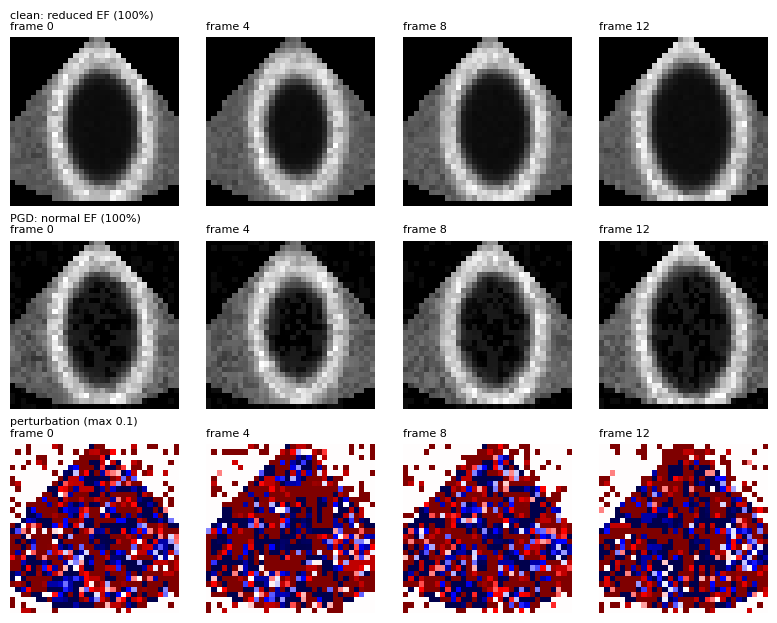

In [5]:
# Look at one attacked video: the diagnosis flips, but the video looks almost the same
with torch.no_grad():
    p_clean, p_adv = standard(x_test[:8]).softmax(1), standard(x_pgd[:8]).softmax(1)
i = int(((p_clean.argmax(1) == y_test[:8]) & (p_adv.argmax(1) != y_test[:8])).float().argmax())
show_frames([x_test[i], x_pgd[i], x_pgd[i] - x_test[i]],
            [f"clean: {CLASSES[p_clean[i].argmax()]} ({p_clean[i].max():.0%})",
             f"PGD: {CLASSES[p_adv[i].argmax()]} ({p_adv[i].max():.0%})",
             f"perturbation (max {EPS})"], cmaps=["gray", "gray", "seismic"])

## 5. A video-specific attack: change only one frame

A video gives the attacker a new choice: *which frames to change*. Here PGD may modify only **frame 8**; the other 15 frames are untouched. With the same per-pixel budget ε, the attack is much weaker, so we also try budgets up to 8 × ε.

In [6]:
one_frame = torch.zeros_like(x_test[:1]); one_frame[:, :, 8] = 1       # only frame 8 may change
print(f"{'budget':>12s}{'all 16 frames':>16s}{'frame 8 only':>15s}")
for k in [1, 2, 4, 8]:
    acc_all = accuracy(standard, attack_all(standard, pgd, eps=k * EPS), y_test)
    acc_one = accuracy(standard, attack_all(standard, pgd, eps=k * EPS, mask=one_frame), y_test)
    print(f"{k} x EPS = {k * EPS:.1f}{acc_all:16.1%}{acc_one:15.1%}")

      budget   all 16 frames   frame 8 only
1 x EPS = 0.1            5.4%          99.4%
2 x EPS = 0.2            0.0%          96.1%
4 x EPS = 0.4            0.0%          66.0%
8 x EPS = 0.8            0.0%          42.8%


## 6. Fast adversarial training

**Adversarial training** replaces each training batch with adversarial examples, so the model learns to classify correctly anywhere inside the ε-ball. Using full PGD for this multiplies the training cost by the number of PGD steps.

**Fast adversarial training** (Wong, Rice & Kolter, *Fast is better than free*, ICLR 2020) uses a single FGSM step from a **random start**, which costs only about 2× normal training and, with the random start, works nearly as well as PGD training.

**ε warm-up.** If we attack with the full ε = EPS from the first step, an untrained model cannot learn anything from such hard examples, and it gets stuck guessing one class (we saw this happen in testing). So `train` grows ε linearly from 0 to EPS over the first 40% of training: the model first learns the task, then learns to be robust.

In [7]:
def fgsm_rs(net, x, y, eps):
    """FGSM with a random start (Wong et al., 2020): the attack used during fast adversarial training."""
    net.eval()
    return pgd(net, x, y, eps, steps=1, alpha=1.25 * eps, random_start=True)

robust = train(adversarial=True)

step  200   loss 0.293      10 s
step  400   loss 0.399      19 s
step  600   loss 0.252      29 s
step  800   loss 0.313      38 s


## 7. Compare the two models

We evaluate both models on the same test videos, attacked with a **stronger** PGD (20 steps) than the single-step attack used in training, and across several budgets ε.

standard training       eps=0.000: 100.0%  eps=0.050: 57.6%  eps=0.100:  4.3%  eps=0.150:  0.1%  eps=0.200:  0.0%
adversarial training    eps=0.000: 99.2%  eps=0.050: 94.5%  eps=0.100: 79.4%  eps=0.150: 54.5%  eps=0.200: 28.9%


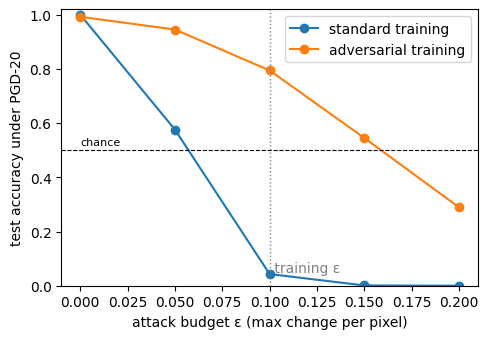

In [8]:
epsilons = [0, EPS / 2, EPS, 1.5 * EPS, 2 * EPS]
results = {}
for name, net in [("standard training", standard), ("adversarial training", robust)]:
    results[name] = [accuracy(net) if e == 0 else
                     accuracy(net, attack_all(net, pgd, eps=e, steps=20), y_test) for e in epsilons]
    print(f"{name:22s}" + "".join(f"  eps={e:.3f}: {a:5.1%}" for e, a in zip(epsilons, results[name])))

plt.figure(figsize=(5, 3.5))
for name, accs in results.items():
    plt.plot(epsilons, accs, "o-", label=name)
plt.axvline(EPS, color="gray", ls=":", lw=1); plt.text(EPS, 0.05, " training ε", color="gray")
plt.axhline(0.5, color="k", ls="--", lw=0.8); plt.text(0, 0.52, "chance", fontsize=8)
plt.xlabel("attack budget ε (max change per pixel)"); plt.ylabel("test accuracy under PGD-20")
plt.ylim(0, 1.02); plt.legend(); plt.tight_layout(); plt.show()

**What to notice** (numbers from our test run; yours will be close):

| Model | Clean | PGD-20, ε = 0.05 | ε = 0.10 (training ε) | ε = 0.15 | ε = 0.20 |
|---|---|---|---|---|---|
| Standard training | 100% | 60% | **5%** | 0% | 0% |
| Fast adversarial training | 100% | 96% | **78%** | 58% | 33% |

- The standard model is perfect on clean videos but **almost always wrong** under an ε = 0.1 attack. For a diagnostic model, this means an invisible change can turn "normal" into "heart failure" or back.
- Adversarial training keeps clean accuracy at 100% here and raises accuracy under the same attack from 5% to 78%, for about 2× the training cost.
- Robustness is **not** a guarantee: beyond the ε used in training, the robust model also degrades. Always report robustness at several budgets, with an attack stronger than the one used in training.
- From section 5: changing a single frame required a much larger (visible) perturbation. The model combines evidence from all 16 frames, and that redundancy makes video models harder to attack one frame at a time.

## Key ideas

| Concept | Meaning |
|---|---|
| Adversarial example | Input + a tiny perturbation (every pixel changes by at most ε) that fools the model |
| FGSM / PGD | One-step / multi-step signed-gradient attacks; PGD is the standard strong attack |
| Video attacks | The perturbation has a time axis: the attacker can spread it over all frames or concentrate it in a few |
| Adversarial training | Train on attacked inputs; robust accuracy goes up, clean accuracy may go down slightly |
| Fast adversarial training | One FGSM step from a random start instead of full PGD: about 2× the cost of standard training |
| Evaluate with a stronger attack | Test robustness with more PGD steps than used in training, and several ε values |

## Next steps

- **Real models:** attack the VideoMAE or X-CLIP models from the *Transformers for Video* tutorial (same `pgd` function; normalize inside the model).
- **Stronger evaluation:** AutoAttack, or PGD with many random restarts, gives more reliable robustness estimates.
- **Medical AI safety:** robustness to perturbations, and to natural shifts such as a different ultrasound machine, is part of validating a clinical model.